In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200
tv = np.random.uniform(10, 300, n)
radio = np.random.uniform(5, 50, n)
social = np.random.uniform(1, 20, n)

df = pd.DataFrame({
    'TV': tv,
    'Radio': radio,
    'Social_Media': social,
    'Sales': tv * 0.15 + radio * 0.12 + social * 0.05 + np.random.normal(0, 3, n)
})

df.to_csv('marketing.csv', index=False)
df.head()

,TV,Radio,Social_Media,Sales
0,118.616634,33.891424,2.959354,20.416661
1,285.707149,8.786298,18.148505,42.439235
2,222.278243,12.273292,10.599795,35.023430
3,183.610960,45.434938,16.702692,30.723244
4,55.245406,32.289308,7.080942,10.854627


In [2]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv('marketing.csv')
print(df.shape)
print(df.isnull().sum())
df.dropna(inplace=True)
df.describe()

(200, 4)
TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64


,TV,Radio,Social_Media,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,150.361808,27.696881,10.892783,26.244047
std,85.518515,13.185054,5.838867,13.157536
min,11.601414,5.227771,1.205915,0.534991
25%,76.288900,16.765813,5.854886,15.434658
50%,153.401013,29.373795,10.982590,24.939770
75%,229.489289,38.398969,16.411183,37.584087
max,296.197212,49.572731,19.994636,50.690151


                    TV     Radio  Social_Media     Sales
TV            1.000000 -0.026887     -0.046239  0.967212
Radio        -0.026887  1.000000     -0.123856  0.072093
Social_Media -0.046239 -0.123856      1.000000 -0.015966
Sales         0.967212  0.072093     -0.015966  1.000000


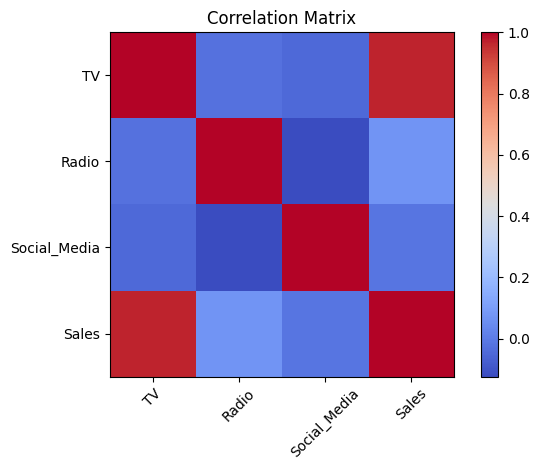

In [3]:
corr = df[['TV', 'Radio', 'Social_Media', 'Sales']].corr()
print(corr)

fig, ax = plt.subplots()
im = ax.imshow(corr, cmap='coolwarm')
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45)
ax.set_yticklabels(corr.columns)
plt.colorbar(im)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[['TV', 'Radio', 'Social_Media']]
X_const = sm.add_constant(X)

vif_data = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X_const.values, i+1) for i in range(X.shape[1])]
})
print(vif_data)

        Feature       VIF
0            TV  1.003229
1         Radio  1.016680
2  Social_Media  1.018122


In [6]:
X = sm.add_constant(df[['TV', 'Radio', 'Social_Media']])
y = df['Sales']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = sm.OLS(y_train, X_train).fit()
print(model.summary())
print(f"\nAdjusted R-squared: {model.rsquared_adj:.4f}")

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.941
Method:                 Least Squares   F-statistic:                     841.1
Date:                Wed, 24 Jun 2026   Prob (F-statistic):           4.64e-96
Time:                        21:25:17   Log-Likelihood:                -410.55
No. Observations:                 160   AIC:                             829.1
Df Residuals:                     156   BIC:                             841.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.2429      0.935     -0.260   

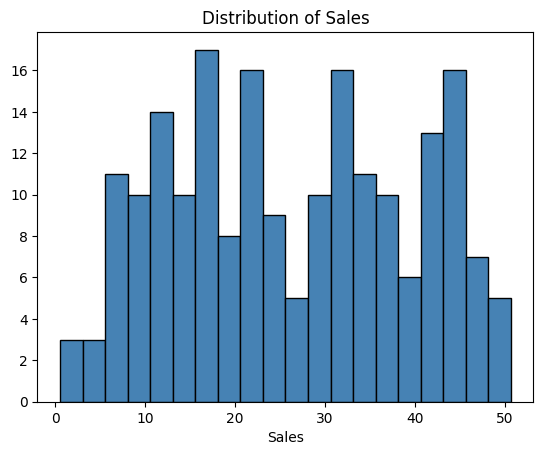

In [7]:
plt.hist(df['Sales'], bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.show()

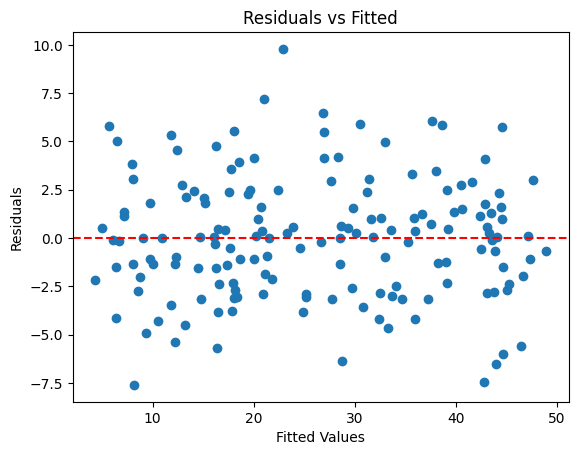

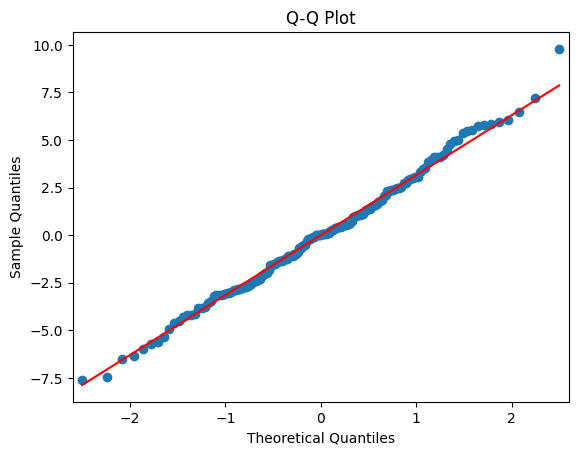

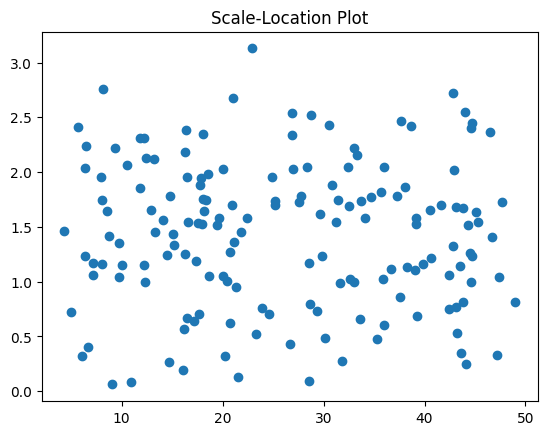

In [8]:
fitted = model.fittedvalues
residuals = model.resid

plt.scatter(fitted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot')
plt.show()

plt.scatter(fitted, np.sqrt(np.abs(residuals)))
plt.title('Scale-Location Plot')
plt.show()

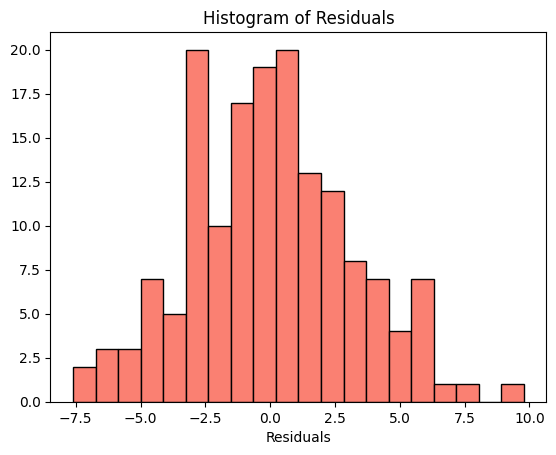

In [9]:
plt.hist(model.resid, bins=20, color='salmon', edgecolor='black')
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.show()

## Model Interpretation

- **Adjusted R-squared**: accounts for number of predictors; more reliable than R-squared
- **TV Coefficient**: holding Radio and Social Media constant, each $1K increase in TV spend is associated with a ~0.15 increase in Sales
- **Radio Coefficient**: holding TV and Social Media constant, each $1K increase in Radio spend is associated with a ~0.12 increase in Sales
- **Social Media Coefficient**: holding TV and Radio constant, each $1K increase in Social Media spend is associated with a ~0.05 increase in Sales
- **P-values**: all predictors < 0.05, confirming statistical significance
- **VIF**: all values below 5, indicating no serious multicollinearity

## Final Equation

Sales = Intercept + 0.15 * TV + 0.12 * Radio + 0.05 * Social_Media

## Business Recommendation

All three channels significantly predict Sales. TV has the strongest impact, followed by Radio and Social Media. Recommend prioritizing TV and Radio budget allocation for maximum ROI while maintaining Social Media presence.